# Seaborn for Beginners

A worked walkthrough of Seaborn's most common plots, using a single dataset throughout:
Seaborn's built-in `tips` dataset.

## 1. What is Seaborn?

Seaborn is a Python library for making statistical charts. It is built directly on top of
Matplotlib, so every Seaborn plot is a Matplotlib plot underneath.

Plain Matplotlib is powerful but low-level: coloring points by a category or adding a trend
line can take many lines of code. Seaborn does that kind of chart in a single function call,
and it works with Pandas DataFrames directly, so you plot columns by name.

| Tool | Role |
|---|---|
| **Pandas** | Loads and organizes the data (DataFrames) |
| **Seaborn** | Turns a DataFrame into a statistical chart |
| **Matplotlib** | The underlying engine, used directly for fine-tuning |

By convention, Seaborn is imported as `sns`.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Seaborn version:", sns.__version__)

Seaborn version: 0.13.2


## 2. Load the Dataset

Every Seaborn plot needs a DataFrame. Before plotting, we check what columns exist, their
types, and whether anything looks unusual.

The `tips` dataset contains restaurant bills; each row is one table's visit.

In [2]:
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
df.shape

(244, 7)

In [4]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [6]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


**Column meanings:**

| Column | Meaning |
|---|---|
| `total_bill` | Total cost of the meal, in dollars |
| `tip` | Tip amount, in dollars |
| `sex` | Sex of the person who paid the bill |
| `smoker` | Whether anyone in the party was a smoker (Yes/No) |
| `day` | Day of the week |
| `time` | Lunch or Dinner |
| `size` | Number of people at the table |

**Numerical columns:** `total_bill`, `tip`, `size`
**Categorical columns:** `sex`, `smoker`, `day`, `time`

Rule of thumb: if it makes sense to take an average of a column, it's numerical.

## 3. First Seaborn Plot: Scatter Plot

A scatter plot draws one dot per row and shows whether two numbers are related.
Here: does a bigger total bill mean a bigger tip?

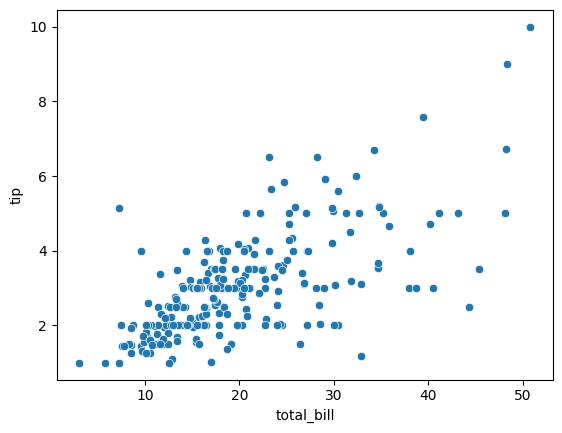

In [7]:
sns.scatterplot(data=df, x="total_bill", y="tip")
plt.show()

- `data=df` is the DataFrame to pull columns from
- `x="total_bill"` and `y="tip"` are the columns for each axis

The dots drift upward from left to right, so bigger bills generally get bigger tips.

The Matplotlib equivalent needs the columns pulled out by hand:

```python
plt.scatter(df["total_bill"], df["tip"])
plt.xlabel("total_bill")
plt.ylabel("tip")
plt.show()
```

The difference grows once we start grouping by color.

## 4. Scatter Plot with `hue`

`hue` colors the points by another column. Seaborn picks the colors and adds the legend
automatically.

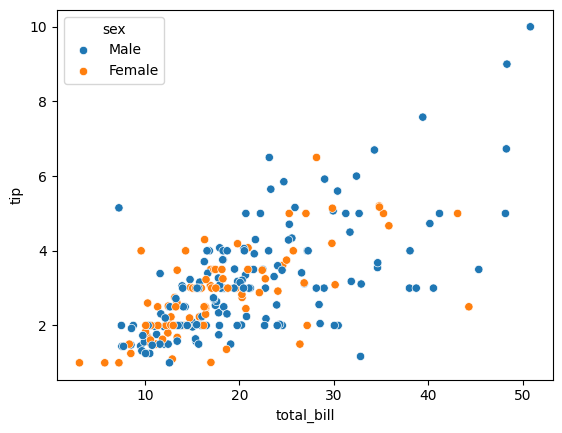

In [8]:
sns.scatterplot(data=df, x="total_bill", y="tip", hue="sex")
plt.show()

Coloring by `smoker`:

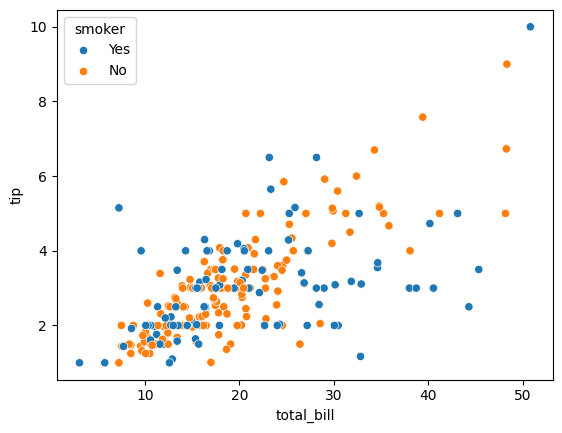

In [9]:
sns.scatterplot(data=df, x="total_bill", y="tip", hue="smoker")
plt.show()

Coloring by `day`:

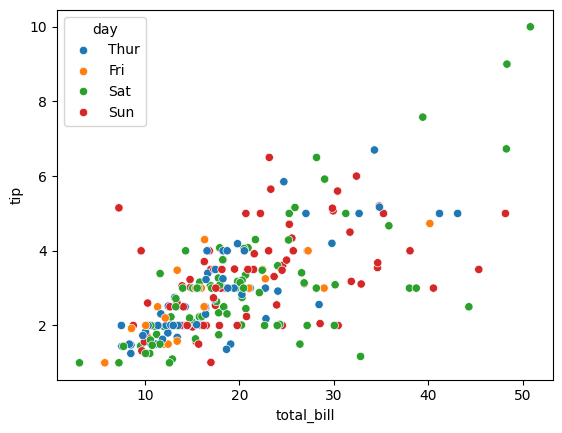

In [10]:
sns.scatterplot(data=df, x="total_bill", y="tip", hue="day")
plt.show()

## 5. Line Plot

Line plots show a trend as one value increases in order. Here: average `tip` by table `size`.

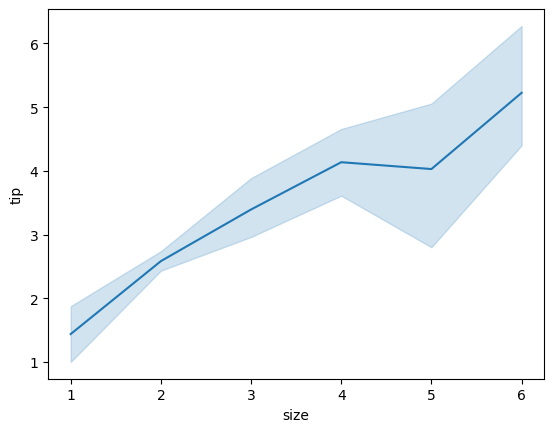

In [11]:
sns.lineplot(data=df, x="size", y="tip")
plt.show()

Seaborn averages `tip` at each `size` and shades a confidence interval around the line,
showing how much the values vary at each point.

## 6. Bar Plot

A bar plot compares a numerical value across categories. Each bar is the average
`total_bill` for that day; the thin line on top is a confidence interval.

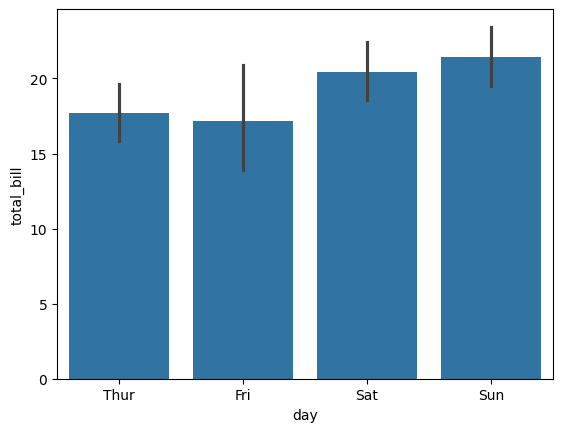

In [12]:
sns.barplot(data=df, x="day", y="total_bill")
plt.show()

Split by `sex` with `hue`:

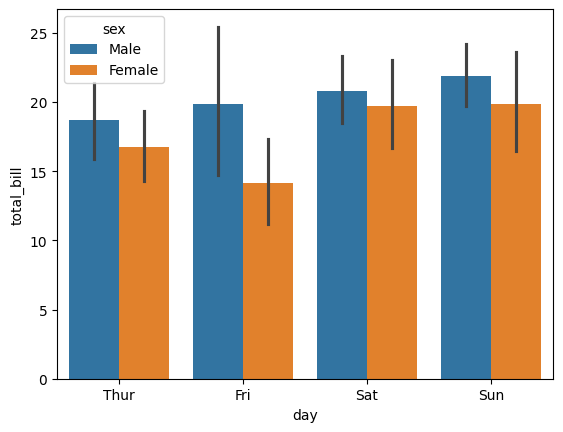

In [13]:
sns.barplot(data=df, x="day", y="total_bill", hue="sex")
plt.show()

**`barplot` vs `countplot`:** `barplot` shows the *average* of a numerical column per category
(needs `x` and `y`). `countplot` shows *how many rows* fall in each category (needs one column).

## 7. Count Plot

`countplot` counts how many rows belong to each category. Only `x` is given; Seaborn does
the counting. The same numbers from Pandas:

In [14]:
df["day"].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

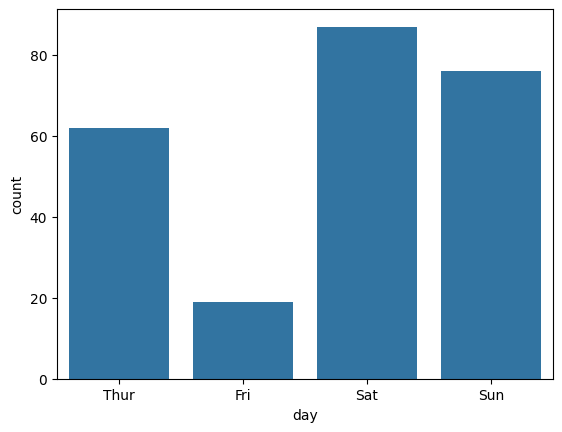

In [15]:
sns.countplot(data=df, x="day")
plt.show()

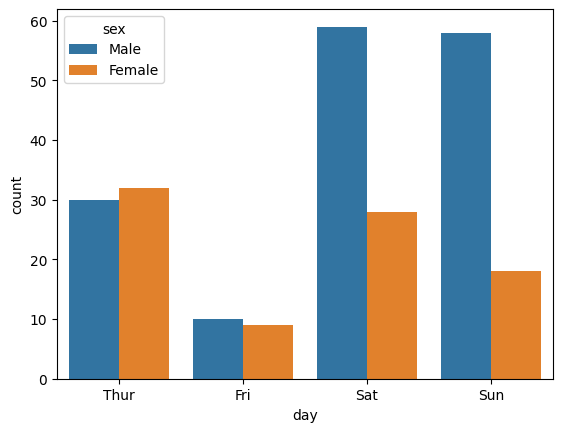

In [16]:
sns.countplot(data=df, x="day", hue="sex")
plt.show()

Lunch vs Dinner, split by `smoker`:

In [17]:
df["time"].value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

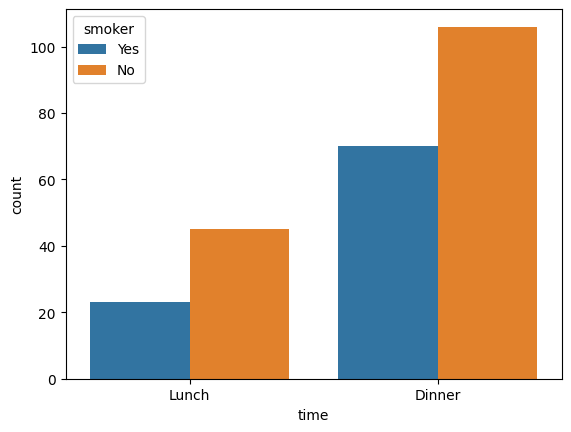

In [18]:
sns.countplot(data=df, x="time", hue="smoker")
plt.show()

## 8. Histogram

A histogram shows the **distribution** of one numerical column.

- The x-axis is split into ranges called **bins**
- Each bar's height is the **frequency**: how many bills fall in that range

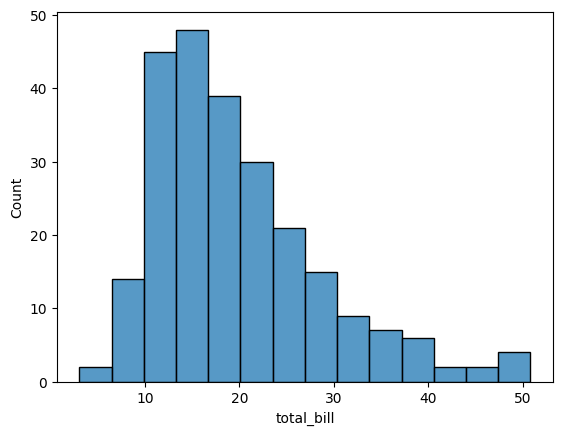

In [19]:
sns.histplot(data=df, x="total_bill")
plt.show()

`kde=True` adds a smoothed curve (kernel density estimate) over the bars, making the overall
shape easier to see.

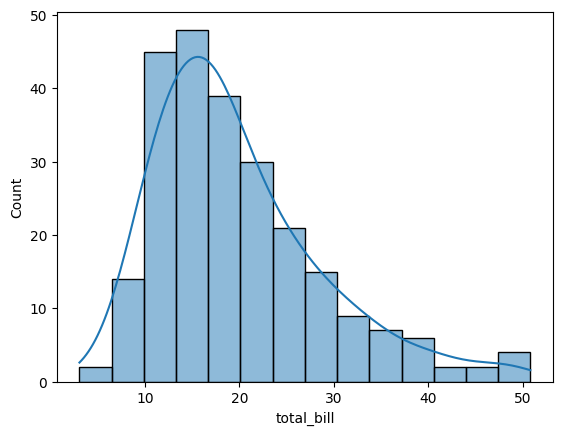

In [20]:
sns.histplot(data=df, x="total_bill", kde=True)
plt.show()

## 9. Box Plot

A box plot summarizes the spread of a numerical column per category:

- The line inside the box is the **median**
- The box covers the middle 50% of values (25th to 75th percentile)
- The whiskers extend to the typical range; dots beyond them are **outliers**

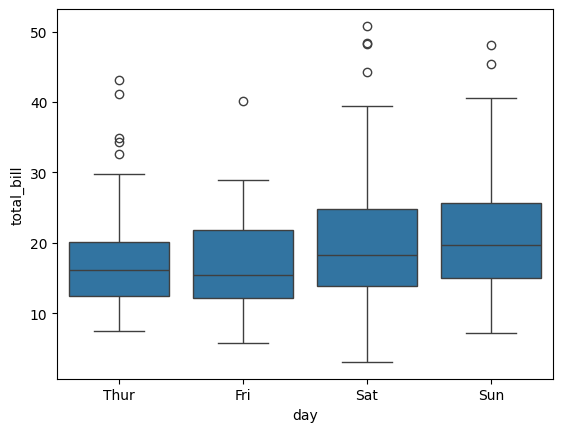

In [21]:
sns.boxplot(data=df, x="day", y="total_bill")
plt.show()

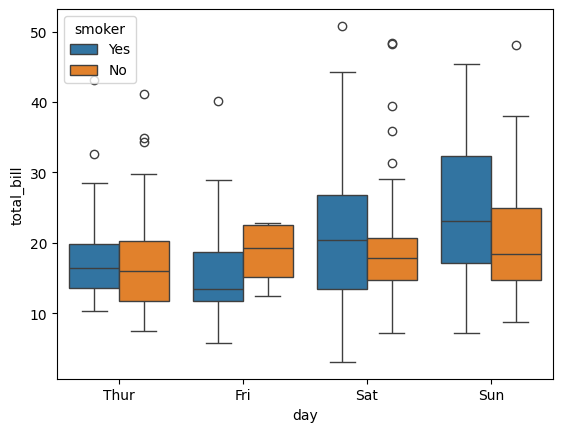

In [22]:
sns.boxplot(data=df, x="day", y="total_bill", hue="smoker")
plt.show()

Weekend bills (Sat/Sun) have higher medians and more high-value outliers than Thursday or Friday.

## 10. Heatmap and Correlation

A **correlation** is a number between -1 and 1 describing how strongly two columns move together:

- Close to **+1**: both go up together
- Close to **-1**: one goes up as the other goes down
- Close to **0**: little to no relationship

A **heatmap** shows the full grid of correlations as colors.

In [23]:
corr = df.select_dtypes("number").corr()
corr

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


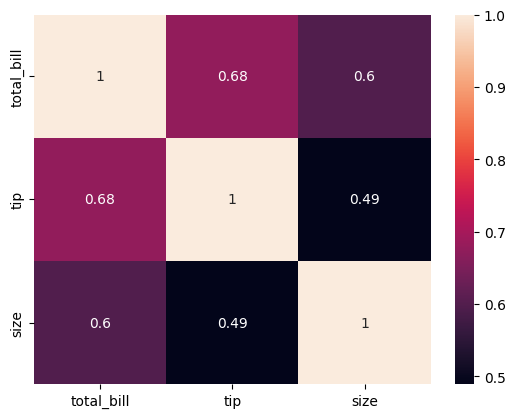

In [24]:
sns.heatmap(corr, annot=True)
plt.show()

`annot=True` writes the value in each square. `total_bill` and `tip` have a strong positive
correlation, matching the first scatter plot.

## 11. Basic Customization

Since Seaborn plots are Matplotlib plots, commands like `plt.title()` work on them directly.

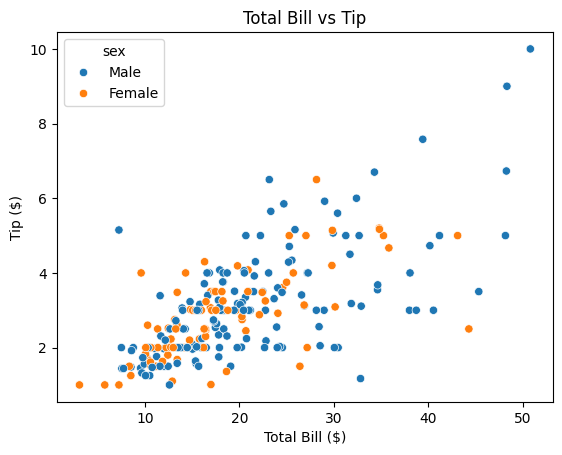

In [25]:
sns.scatterplot(data=df, x="total_bill", y="tip", hue="sex")
plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.show()

`sns.set_theme()` changes the style of every plot drawn after it.

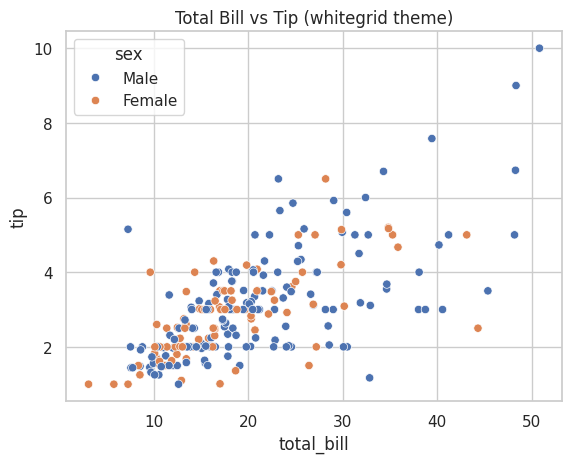

In [26]:
sns.set_theme(style="whitegrid")

sns.scatterplot(data=df, x="total_bill", y="tip", hue="sex")
plt.title("Total Bill vs Tip (whitegrid theme)")
plt.show()

`sns.set_theme()` controls the overall style (background, grid, palette) for all plots;
Matplotlib commands like `plt.title()` customize one plot at a time.

## 12. Important Seaborn Parameters

| Parameter | Meaning |
|---|---|
| `data=` | Which DataFrame to plot from |
| `x=` | Column for the horizontal axis |
| `y=` | Column for the vertical axis |
| `hue=` | Column used for **color** grouping |
| `style=` | Column used for **marker shape / line style** grouping |
| `size=` | Column used for **point / line size** grouping |

`style` and `size` work like `hue`, controlling shape and size instead of color:

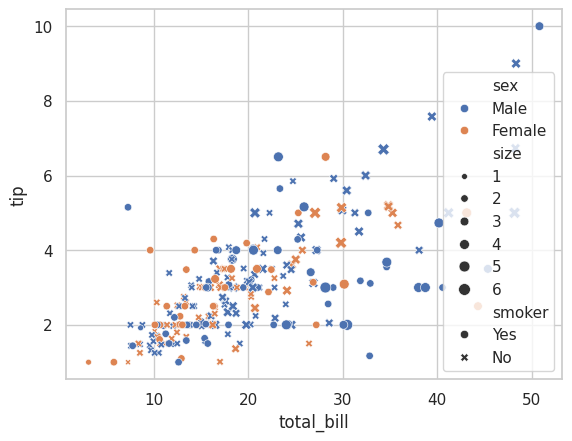

In [27]:
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="sex",
    style="smoker",
    size="size"
)
plt.show()

## 13. Practice Project

Seven plots on the `tips` dataset, combining everything above.

**Task 1: Scatter plot of `total_bill` vs `tip`**

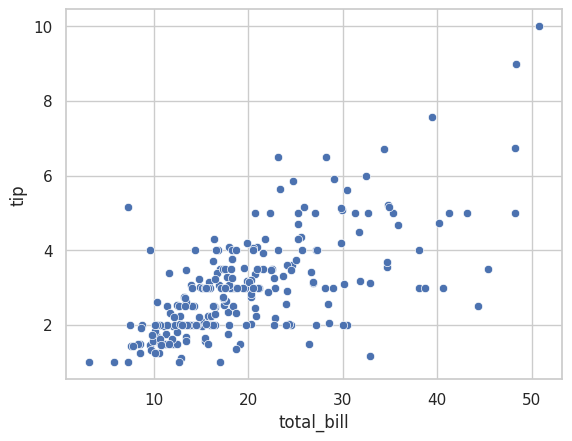

In [28]:
sns.scatterplot(data=df, x="total_bill", y="tip")
plt.show()

**Task 2: Same scatter plot, separating smokers from non-smokers with `hue`**

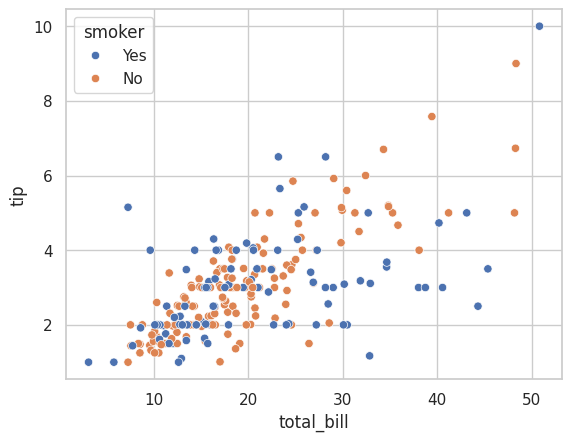

In [29]:
sns.scatterplot(data=df, x="total_bill", y="tip", hue="smoker")
plt.show()

**Task 3: Count plot of `day`**

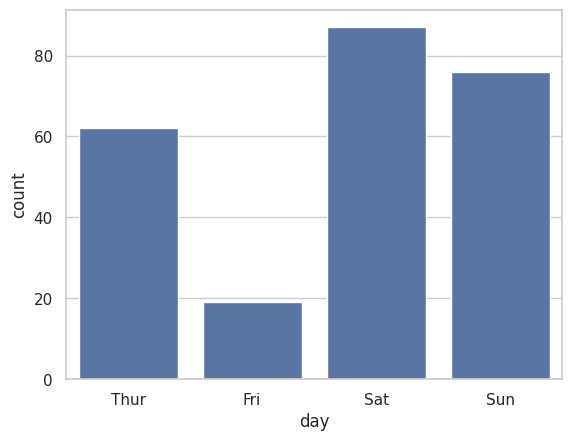

In [30]:
sns.countplot(data=df, x="day")
plt.show()

**Task 4: Bar plot of average `total_bill` by `day`**

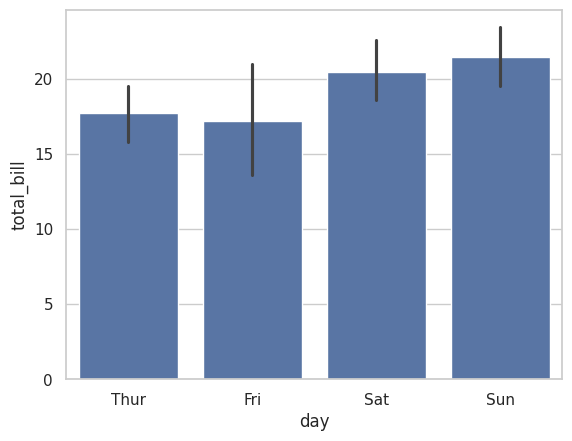

In [31]:
sns.barplot(data=df, x="day", y="total_bill")
plt.show()

**Task 5: Histogram of `total_bill`**

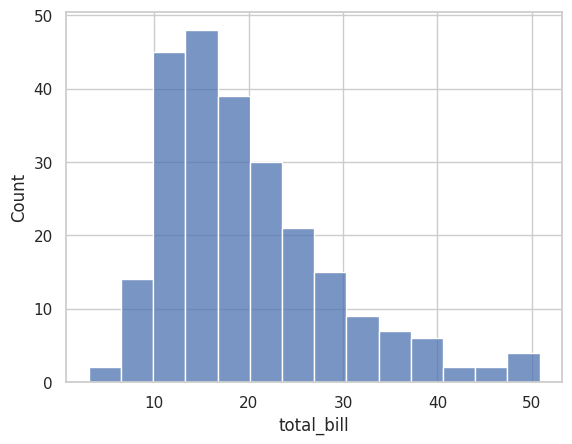

In [32]:
sns.histplot(data=df, x="total_bill")
plt.show()

**Task 6: Box plot of `total_bill` by `day`**

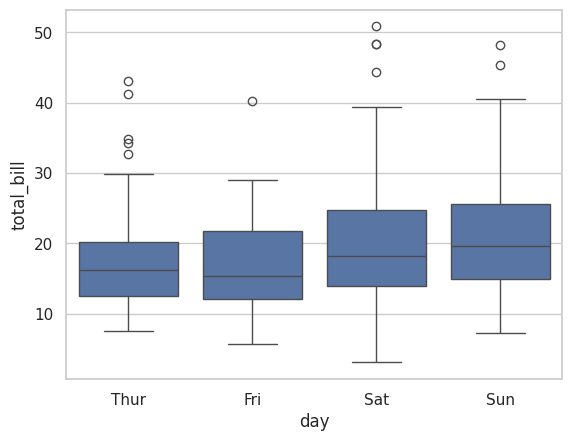

In [33]:
sns.boxplot(data=df, x="day", y="total_bill")
plt.show()

**Task 7: Heatmap of the numerical correlations**

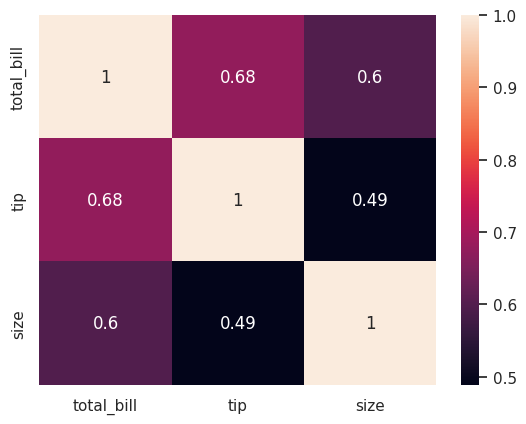

In [34]:
corr = df.select_dtypes("number").corr()
sns.heatmap(corr, annot=True)
plt.show()

## 14. Beyond the Basics

Four more tools that build on the same `data` / `x` / `y` / `hue` pattern:
`pairplot()`, `violinplot()`, regression plots, and `FacetGrid`.

### 14.1 Pair Plot

`pairplot()` draws a scatter plot for every pair of numerical columns, with each column's
distribution on the diagonal. It's a quick way to scan all relationships at once.

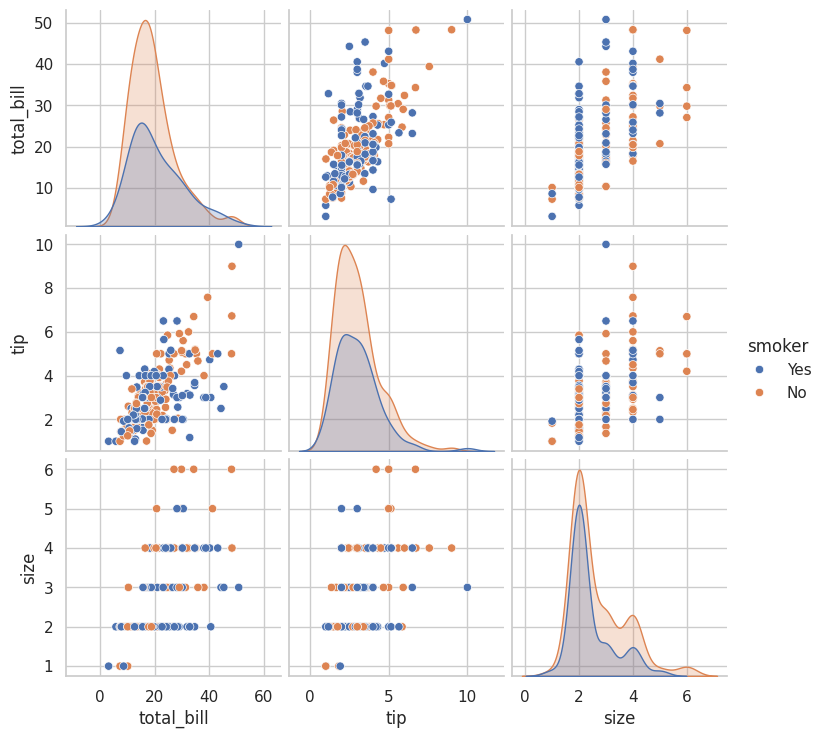

In [35]:
sns.pairplot(data=df, hue="smoker")
plt.show()

### 14.2 Violin Plot

A violin plot combines a box plot with a KDE curve: the width at each height shows how many
values sit there. It reveals the *shape* of each group's distribution, not just its quartiles.

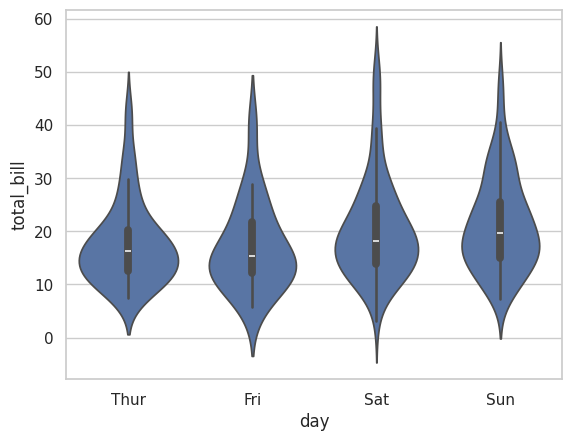

In [36]:
sns.violinplot(data=df, x="day", y="total_bill")
plt.show()

With `hue` and `split=True`, the two groups share one violin, one on each side:

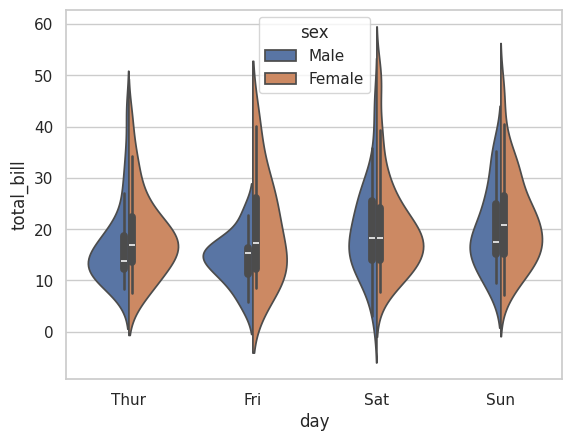

In [37]:
sns.violinplot(data=df, x="day", y="total_bill", hue="sex", split=True)
plt.show()

### 14.3 Regression Plots

`regplot()` draws a scatter plot plus a fitted straight line with a confidence band.

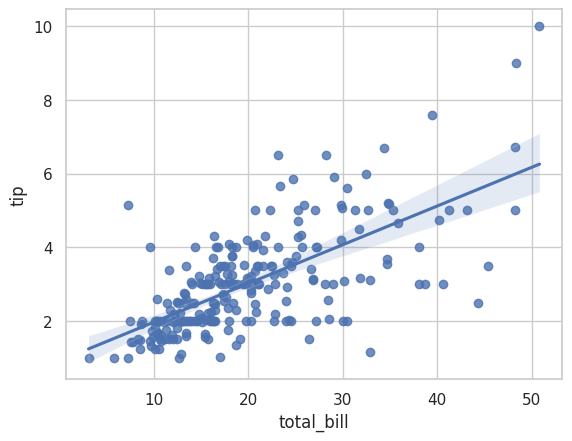

In [38]:
sns.regplot(data=df, x="total_bill", y="tip")
plt.show()

`lmplot()` does the same but supports `hue`, fitting a separate line per group:

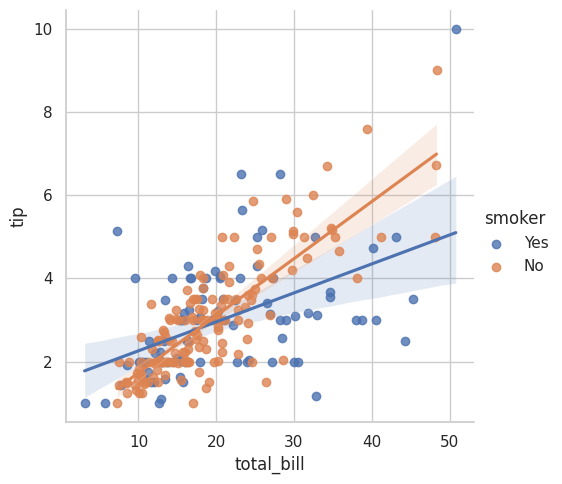

In [39]:
sns.lmplot(data=df, x="total_bill", y="tip", hue="smoker")
plt.show()

The line for non-smokers is steeper: their tips rise more with the bill than smokers' do.

### 14.4 FacetGrid

`FacetGrid` repeats the same plot in a grid of panels, one per category. `col` and `row`
choose which columns split the panels, and `.map_dataframe()` says what to draw in each.

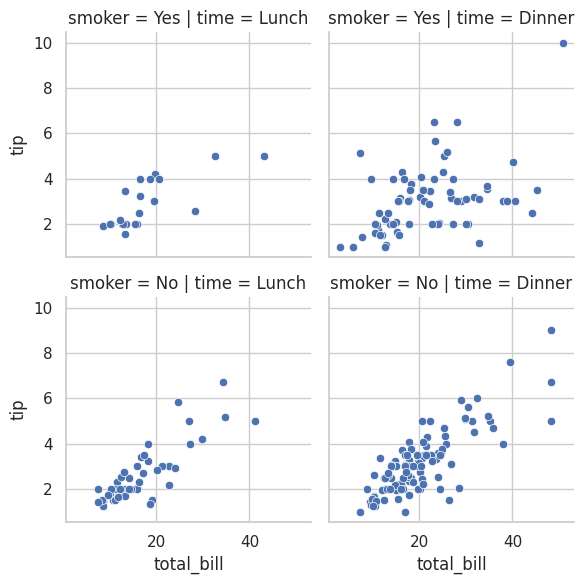

In [40]:
g = sns.FacetGrid(df, col="time", row="smoker")
g.map_dataframe(sns.scatterplot, x="total_bill", y="tip")
plt.show()

Figure-level functions like `relplot()`, `displot()` and `catplot()` build a FacetGrid
for you in one call:

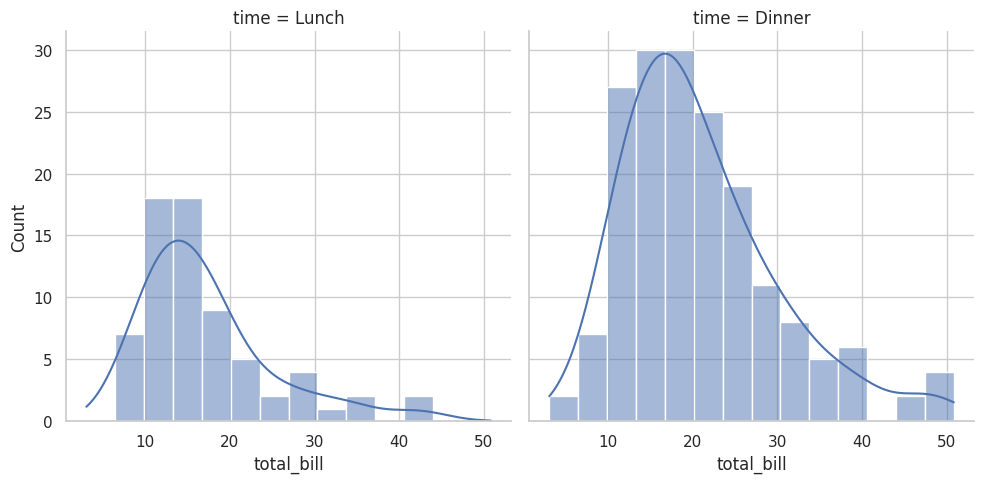

In [41]:
sns.displot(data=df, x="total_bill", col="time", kde=True)
plt.show()

### 14.5 Deeper Customization

Palettes, figure size, and axis-level control via the `ax` returned by every axes-level
Seaborn function:

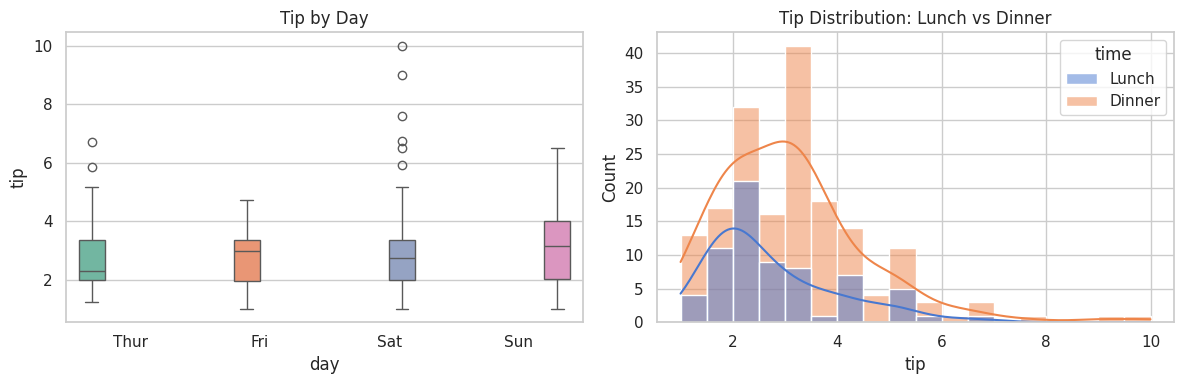

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x="day", y="tip", palette="Set2", hue="day", legend=False, ax=axes[0])
axes[0].set_title("Tip by Day")

sns.histplot(data=df, x="tip", hue="time", kde=True, palette="muted", ax=axes[1])
axes[1].set_title("Tip Distribution: Lunch vs Dinner")

plt.tight_layout()
plt.show()

## 15. Cheat Sheet

| Purpose | Seaborn Function |
|---|---|
| Relationship between two numbers | `scatterplot()` |
| Trend across an ordered value | `lineplot()` |
| Compare a number across categories | `barplot()` |
| Count rows per category | `countplot()` |
| Distribution of one number | `histplot()` |
| Spread / outliers per category | `boxplot()` |
| Distribution shape per category | `violinplot()` |
| Correlation between numbers | `heatmap()` |
| All pairwise relationships | `pairplot()` |
| Scatter + fitted line | `regplot()` / `lmplot()` |
| Same plot split into panels | `FacetGrid`, `relplot()`, `displot()`, `catplot()` |

**Basic syntax pattern:**

```python
sns.plot_function(
    data=df,
    x="column",
    y="column",
    hue="column"
)
```

## 16. Summary

- **Seaborn** is built on Matplotlib and makes statistical charts from a Pandas DataFrame in one call
- Most plots follow the pattern `sns.plot_function(data=df, x=..., y=..., hue=...)`
- **`hue`** colors points or bars by a category
- **scatterplot** and **lineplot** show relationships and trends between two numbers
- **barplot** compares averages across categories; **countplot** compares raw counts
- **histplot**, **boxplot** and **violinplot** describe distributions and spread
- **heatmap** shows correlation between every pair of numerical columns
- **pairplot** scans all pairwise relationships; **regplot / lmplot** add fitted lines
- **FacetGrid** (and `relplot` / `displot` / `catplot`) split one plot into panels by category
- Matplotlib (`plt.title()`, `ax=`, `figsize`) still works on top of any Seaborn plot, and `sns.set_theme()` sets the overall look